<a href="https://colab.research.google.com/github/juanepstein99/DI_Bootcamp/blob/main/Week11/Day4/ExercisesXP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Exercises XP - Diabetes Classification

## What you will learn
- Understanding the problem
- Data collection
- Model training for classification
- Model evaluation

## What you will create
- A Logistic Regression model to predict diabetes


In [3]:
# imports

import pandas as pd    # Dataframes
import numpy as np     # arrays
import matplotlib.pyplot as plt    # Visualization
import seaborn as sns              # Visualization
import sklearn                   # Machine Learning

print("Libraries loaded!")
print(f"  NumPy   : {np.__version__}")
print(f"  Pandas  : {pd.__version__}")
print(f"  Seaborn : {sns.__version__}")
print(f"  Scikit-learn version: {sklearn.__version__}")

from sklearn.model_selection import train_test_split   #split

# PREPROCESING

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder  # scaling and encoding

from sklearn.pipeline import Pipeline    #Pipeline
from sklearn.linear_model import LogisticRegression  #Model

# confusion matrix & evaluation
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report
    )

from sklearn import metrics

# Display settings
%matplotlib inline
plt.rcParams['figure.figsize'] = (8, 5)
sns.set_style('whitegrid')


Libraries loaded!
  NumPy   : 2.0.2
  Pandas  : 2.2.2
  Seaborn : 0.13.2
  Scikit-learn version: 1.6.1



## Exercise 1 - Understanding the problem and Data Collection

We want to predict if an individual has diabetes.

- Load the diabetes dataset and explore it
- Count positive and negative cases
- Split the data into train and test


In [5]:
# Load the diabetes dataset and explore it

df= pd.read_csv('diabetes_prediction_dataset.csv')

print(df.shape)   #(100.000 patients, 9 columns)

print()

display(df.head())


(100000, 9)



,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [6]:
# Data Types
print(df.dtypes)

# Data Types Necesary Transformation:  gender, smoking_history
print()

print("Missing per column:")
display(df.isna().sum().sort_values(ascending=False))  #no missing values

gender                  object
age                    float64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object

Missing per column:


,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


In [8]:
df.duplicated().sum()
# 3854  duplicates ! Since I don't have an ID, I'm not going to delete them.

np.int64(3854)

In [9]:
display(df.describe())

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [10]:
df.describe(include='object')

,gender,smoking_history
count,100000,100000
unique,3,6
top,Female,No Info
freq,58552,35816


In [11]:
# gender treatment

print(df['gender'].value_counts()) #18 records without correct Gender (0.018%) — removed to avoid noise
df = df[df['gender'] != 'Other']
print(f"Dataset after removing 'Other': {df.shape}")

gender
Female    58552
Male      41430
Other        18
Name: count, dtype: int64
Dataset after removing 'Other': (99982, 9)


In [12]:
# smoking_history treatment
print (df['smoking_history'].unique())

df['smoking_history'] = df['smoking_history'].replace({'former': 'not current'})   # 'former' ~ 'not current'

print(df['smoking_history'].value_counts())

['never' 'No Info' 'current' 'former' 'ever' 'not current']
smoking_history
No Info        35810
never          35092
not current    15791
current         9286
ever            4003
Name: count, dtype: int64


In [13]:
# Count positive and negative cases

class_names = {0:'Healthy', 1:'Diabetic'}

counts = df['diabetes'].value_counts().rename(index=class_names)
percent = df['diabetes'].value_counts(normalize=True).rename(index=class_names) * 100

df_summary = pd.DataFrame({
    'count': counts,
    'percentage': percent.round(2)
})

print ('How many are healthy and how many are diabetic ?')
print(df_summary)
# unbalanced dataset, with significantly more healthy than diabetic cases (this explains later the high accuracy but lower recall).

How many are healthy and how many are diabetic ?
          count  percentage
diabetes                   
Healthy   91482        91.5
Diabetic   8500         8.5


In [14]:
# Split the data into train and test

X = df.drop(columns=['diabetes'])   # X → variables
y = df['diabetes']  # what I want to predict

display(X.head())
display(y.head())

# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,   # 80% training / 20% testing
    random_state=42,  #random seed
    stratify = y)  # same proportion of diabetics in training and in test


print(X_train.shape, X_test.shape)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level
0,Female,80.0,0,1,never,25.19,6.6,140
1,Female,54.0,0,0,No Info,27.32,6.6,80
2,Male,28.0,0,0,never,27.32,5.7,158
3,Female,36.0,0,0,current,23.45,5.0,155
4,Male,76.0,1,1,current,20.14,4.8,155


,diabetes
0,0
1,0
2,0
3,0
4,0


(79985, 8) (19997, 8)



## Exercise 2 - Model picking and standardization

- Which model can we use and why
- Do we need to standardize
- If yes, apply StandardScaler



> TODO: In a short paragraph, justify Logistic Regression for this binary task. Mention linear decision boundary, calibrated probabilities, and interpretability. Explain why standardization helps for numerical stability and better conditioning.


In [15]:
# Build a preprocessing pipeline

# [ColumnTransformer - StandardScaler - OrdinalEncoder - OneHotEncoder]

num_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()    # INT64 + FLOAT64 --> NUMERICAL
ordinal_cols = ['smoking_history']  # OBJECT -->  CATEGORICAL ordinal
cat_cols = [c for c in X.select_dtypes(include=['object']).columns if c not in ordinal_cols] # OBJECT -->  CATEGORICAL nominal


smoking_order = ['No Info', 'never', 'ever', 'not current', 'current']  #from less exposure to more exposure

preprocess = ColumnTransformer([
    ('num', StandardScaler(), num_cols),      # scaling to NUMERICAL
    ('ord', OrdinalEncoder(categories=[smoking_order]), ordinal_cols),  # ordinal encoding to ORDINAL
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)    # ONE-HOT ENCODING to CATEGORICAL
])

print("Numeric:", num_cols)
print("Categorical:", ordinal_cols, cat_cols, )

Numeric: ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level']
Categorical: ['smoking_history'] ['gender']


## Exercise 3 - Model training

In [16]:
# Train Logistic Regression

clf = Pipeline([
    ('preprocess', preprocess),
    ('model', LogisticRegression(max_iter=1000))
])

clf.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'hypertension',
                                                   'heart_disease', 'bmi',
                                                   'HbA1c_level',
                                                   'blood_glucose_level']),
                                                 ('ord',
                                                  OrdinalEncoder(categories=[['No '
                                                                              'Info',
                                                                              'never',
                                                                              'ever',
                                                                              'not '
                                                                              'current',
                                                                              'current']]),
                                                  ['smoking_history']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender'])])),
                ('model', LogisticRegression(max_iter=1000))])


## Exercise 4 - Evaluation metrics

- Plot accuracy and comment
- Plot confusion matrix and comment
- Plot precision, recall, F1 and comment


Accuracy: 0.962
Precision: 0.881
Recall: 0.635
F1: 0.738


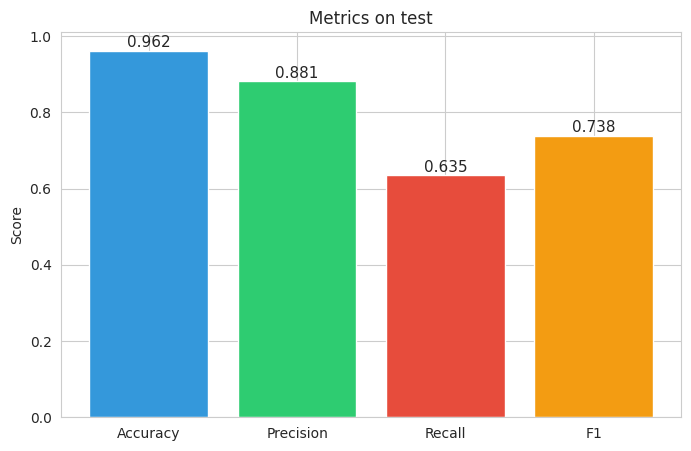

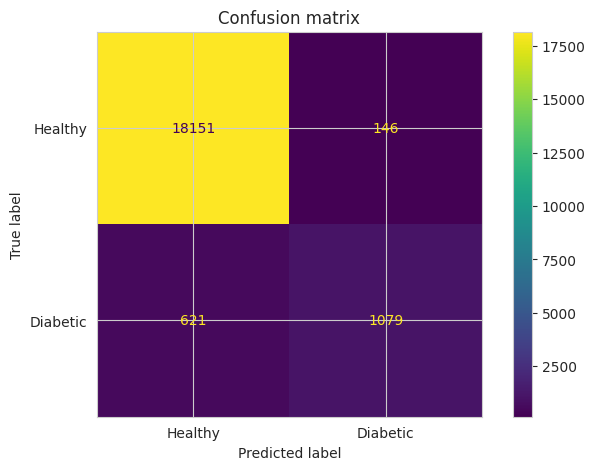

In [17]:
# Use the metrics functions properly to plot the scores

y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", round(acc,3))
print("Precision:", round(prec,3))
print("Recall:", round(rec,3))
print("F1:", round(f1,3))

# bar plot of metrics
colors = ['#3498DB','#2ECC71','#E74C3C','#F39C12']
bars = plt.bar(['Accuracy','Precision','Recall','F1'],
               [acc, prec, rec, f1], color=colors)
for bar, val in zip(bars, [acc, prec, rec, f1]):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', fontsize=11)
plt.title('Metrics on test')
plt.ylabel('Score')
plt.show()

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Healthy", "Diabetic"])
disp.plot()
plt.title('Confusion matrix')
plt.show()

Comment on the balance between precision and recall.

Although the overall accuracy is high, the recall is relatively low (0.64), meaning that a significant number of diabetic patients are not being detected. In a medical context, this is a critical limitation, and improving recall should be prioritized.

* Accuracy: 0.962 (global)

* Precision: 0.881 = how many predicted diabetic cases are actually correct

* Recall: 0.635 = how many actual diabetic cases were correctly identified --> ~36% of diabetic cases are not being detected!

* F1: 0.738 = balance precision & recall


## Exercise 5 - Visualizing the performance of our model

Visualize a 2D decision boundary with accuracy info. Use only two informative features for this plot to keep it 2D. Suggested pair: `HbA1c_level` and `blood_glucose_level` if present. Otherwise pick any two numeric features.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


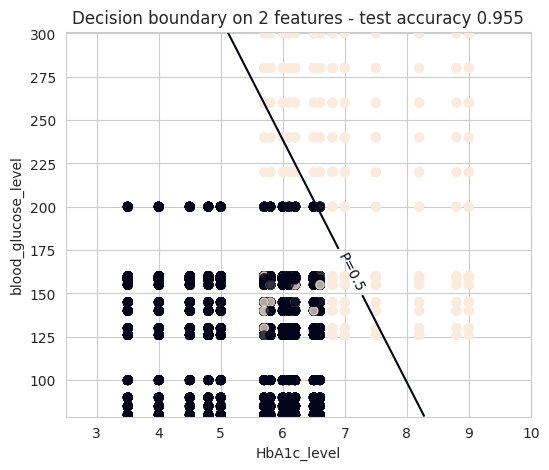

In [18]:
# If these columns do not exist, change `feat_x` and `feat_y` below to two numeric features that exist in your data.

feat_x = 'HbA1c_level' if 'HbA1c_level' in X.columns else X.select_dtypes(include=['int64','float64']).columns[0]
feat_y = 'blood_glucose_level' if 'blood_glucose_level' in X.columns else X.select_dtypes(include=['int64','float64']).columns[1]

X2_train = X_train[[feat_x, feat_y]].copy()
X2_test = X_test[[feat_x, feat_y]].copy()

pipe2 = Pipeline([
    ('pre', ColumnTransformer([('num', StandardScaler(), [0,1])], remainder='drop')),
    ('lr', LogisticRegression(max_iter=1000, random_state=42))
])
pipe2.fit(X2_train, y_train)

# Mesh
x_min, x_max = X2_train[feat_x].min()-1, X2_train[feat_x].max()+1
y_min, y_max = X2_train[feat_y].min()-1, X2_train[feat_y].max()+1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
probs = pipe2.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:,1].reshape(xx.shape)

plt.figure(figsize=(6,5))
cs = plt.contour(xx, yy, probs, levels=[0.5])
plt.clabel(cs, inline=True, fmt={0.5:'P=0.5'})
plt.scatter(X2_test[feat_x], X2_test[feat_y], c=y_test, alpha=0.7)
plt.xlabel(feat_x); plt.ylabel(feat_y)
acc2 = accuracy_score(y_test, pipe2.predict(X2_test))
plt.title(f'Decision boundary on 2 features - test accuracy {acc2:.3f}')
plt.show()


## Exercise 6 - ROC curve

Use the code template provided to plot the ROC curve for your model and compute AUC. You can reuse the fitted `clf` pipeline.

Template summary:
- Get predicted probabilities for the positive class
- Compute fpr and tpr with `roc_curve`
- Plot ROC and print AUC


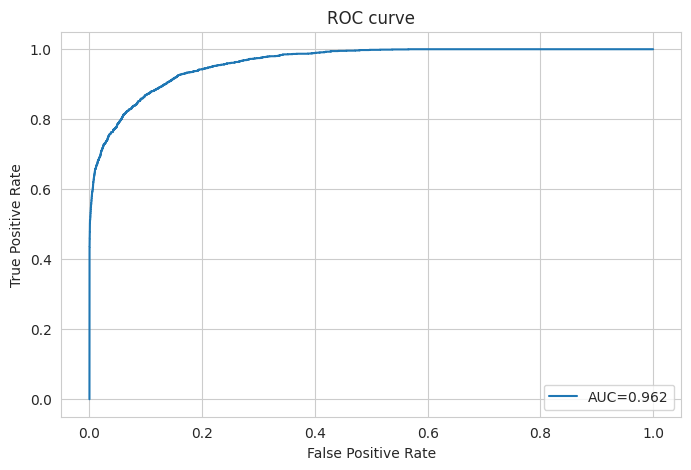

In [19]:
# ROC curve

y_proba = clf.predict_proba(X_test)[:,1]
fpr, tpr, _ = metrics.roc_curve(y_test, y_proba)
auc = metrics.roc_auc_score(y_test, y_proba)

plt.figure()
plt.plot(fpr, tpr, label=f'AUC={auc:.3f}')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.legend(loc=4)
plt.title('ROC curve')
plt.show()

The ROC curve is close to the top-left corner, showing that the model achieves a high true positive rate with a low false positive rate across different thresholds. The AUC score of 0.962 indicates excellent discriminatory power, meaning the model is highly effective at distinguishing between diabetic and non-diabetic patients. Despite this strong performance, it is still important to consider recall and precision, especially in a medical context where missing a positive case can have serious consequences.

**Key Insights**
* The model performs very well overall (AUC = 0.962), effectively separating diabetic and healthy patients.
* Recall is lower (0.635), ~36% of diabetic cases are not being detected — a potential risk in healthcare.
* Improvements could include threshold adjustment, class balancing, or exploring alternative models to boost recall.

            feature  coefficient
      gender_Female    -1.919450
        gender_Male    -1.686468
    smoking_history     0.137976
      heart_disease     0.144346
       hypertension     0.206853
                bmi     0.595153
                age     1.024643
blood_glucose_level     1.359302
        HbA1c_level     2.481834



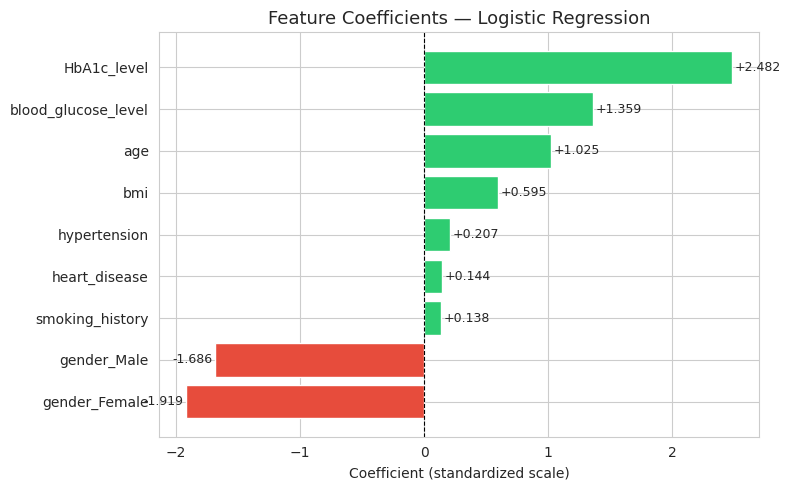

In [20]:
# MODEL COEFFICIENTS

# Extract feature names after the pipeline
ohe_features = clf.named_steps['preprocess'] \
                  .named_transformers_['cat'] \
                  .get_feature_names_out(cat_cols).tolist()

feature_names = num_cols + ordinal_cols + ohe_features

# Coefficients DataFrame
coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': clf.named_steps['model'].coef_[0]
}).sort_values('coefficient', ascending=True)

print(coef_df.to_string(index=False))

print()

# Visualization
colors = ['#E74C3C' if c < 0 else '#2ECC71' for c in coef_df['coefficient']]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Feature Coefficients — Logistic Regression', fontsize=13)
ax.set_xlabel('Coefficient (standardized scale)')

for bar, val in zip(bars, coef_df['coefficient']):
    x_pos = val + 0.02 if val >= 0 else val - 0.02
    ha = 'left' if val >= 0 else 'right'
    ax.text(x_pos, bar.get_y() + bar.get_height() / 2,
            f'{val:+.3f}', va='center', ha=ha, fontsize=9)

plt.tight_layout()
plt.show()

* Blood glucose level and HbA1c are by far the strongest predictors of diabetes, which makes clinical sense as both are directly used in diagnosis.
* BMI and age follow as relevant risk factors.
* Higher smoking exposure also increases risk, validating the OrdinalEncoder approach.
* Being female slightly reduces the predicted probability compared to male.

In [21]:
# BONUS: Improving Recall

# OPTION 1: class_weight='balanced'
# Tells the model to penalize errors on the minority class (Diabetic) more heavily
clf_balanced = Pipeline([
    ('preprocess', preprocess),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
])
clf_balanced.fit(X_train, y_train)
y_pred_bal = clf_balanced.predict(X_test)

# OPTION 2: Threshold adjustment (using the original model)
# Instead of the default threshold of 0.5, we lower it to 0.3
y_pred_thresh = (clf.predict_proba(X_test)[:,1] >= 0.3).astype(int)

results = pd.DataFrame({
    'Model':     ['Original (t=0.5)', 'Balanced weights', 'Lower threshold (t=0.3)'],
    'Accuracy':  [accuracy_score(y_test, y_pred),
                  accuracy_score(y_test, y_pred_bal),
                  accuracy_score(y_test, y_pred_thresh)],
    'Precision': [precision_score(y_test, y_pred),
                  precision_score(y_test, y_pred_bal),
                  precision_score(y_test, y_pred_thresh)],
    'Recall':    [recall_score(y_test, y_pred),
                  recall_score(y_test, y_pred_bal),
                  recall_score(y_test, y_pred_thresh)],
    'F1':        [f1_score(y_test, y_pred),
                  f1_score(y_test, y_pred_bal),
                  f1_score(y_test, y_pred_thresh)],
}).round(3)

display(results)

# Improving recall comes at the cost of precision — this is the classic trade-off in medical models.
# In healthcare, we prefer to detect more cases (high recall) even if it means more false positives.

,Model,Accuracy,Precision,Recall,F1
0,Original (t=0.5),0.962,0.881,0.635,0.738
1,Balanced weights,0.888,0.424,0.884,0.573
2,Lower threshold (t=0.3),0.954,0.731,0.724,0.728
